In [23]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro import optim
from numpyro.infer import SVI, Trace_ELBO, autoguide
import optax
from jax.example_libraries import stax

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../notebooks/matplotlibrc")

[gpu(id=0)]


In [16]:
sys.path.append("..")
from likelihoods.pll_jax import log_like_poisson
from utils.multi_corner import multi_corner
from utils.validation import find_hdi_prob, roc_finite_sample_band

In [5]:
class RandomModel:

    def __init__(self, rng_key, size, n_temp):
        self.size = size
        self.n_temp = n_temp

        temps = []
        for _ in range(n_temp):
            rng_key, key = jax.random.split(rng_key)
            temp = jax.random.uniform(rng_key, shape=(self.size,))
            temp /= jnp.mean(temp)
            temps.append(temp)
        self.temps = jnp.array(temps)

    def set_truth(self, truth_arr):
        self.truth_arr = truth_arr
        self.mu = jnp.einsum('i,ij->j', truth_arr, self.temps)

    def generate_counts(self, rng_key):
        return jax.random.poisson(rng_key, self.mu)
    
    def model(self):
        mu = jnp.zeros((self.size,))
        for i in range(self.n_temp):
            mu += self.temps[i] * numpyro.sample(f'temp_{i}', dist.Uniform(0, 10))
        return mu

    def conditioned_model(self, counts=...):
        mu = self.model()
        with numpyro.plate("data", size=len(mu), dim=-1):
            ll = log_like_poisson(mu, counts)
            return numpyro.factor('log-likelihood', ll)
        
    def fit_svi(
        self, rng_key=jax.random.PRNGKey(42),
        guide='iaf', num_flows=5, hidden_dims=[256, 256],
        n_steps=7500, lr=5e-5, num_particles=8,
        **model_static_kwargs,
    ):
        if guide == 'iaf':
            self.guide = autoguide.AutoIAFNormal(
                self.conditioned_model,
                num_flows=num_flows,
                hidden_dims=hidden_dims,
                nonlinearity=stax.Tanh
            )
        elif guide == 'mvn':
            self.guide = autoguide.AutoMultivariateNormal(self.conditioned_model)
        else:
            raise NotImplementedError
        
        optimizer = optim.optax_to_numpyro(
            optax.chain(
                optax.clip(1.),
                optax.adamw(lr),
            )
        )
        self.svi_model_static_kwargs = model_static_kwargs
        svi = SVI(
            self.conditioned_model, self.guide, optimizer,
            Trace_ELBO(num_particles=num_particles),
            **self.svi_model_static_kwargs,
        )
        self.svi_results = svi.run(rng_key, n_steps)
        
        return self.svi_results
    
    def get_svi_samples(self, num_samples, rng_key=jax.random.PRNGKey(42)):
        self.svi_samples = self.guide.sample_posterior(
            rng_key=rng_key,
            params=self.svi_results.params,
            sample_shape=(num_samples,)
        )
        return self.svi_samples

In [51]:
# config
n_temp = 100
n_run = 30
test = False

# init
p_runs = []
rng_key = jax.random.PRNGKey(42)

rng_key, key = jax.random.split(rng_key)
rm = RandomModel(key, 6400, n_temp)
rng_key, key = jax.random.split(rng_key)
truth_arr = jax.random.normal(key, shape=(n_temp,)) * 0.5 + 3
truth_dict = {f'temp_{i}' : t for i, t in enumerate(truth_arr)}
rm.set_truth(truth_arr)

for i_run in range(n_run if not test else 1):
    print(f'{i_run}:')
    rng_key, key = jax.random.split(rng_key)
    counts = rm.generate_counts(key)
    rng_key, key = jax.random.split(rng_key)
    rm.fit_svi(key, guide='iaf', num_flows=5, hidden_dims=[128, 128],
               n_steps=5000, lr=5e-5, num_particles=8, counts=counts)
    rng_key, key = jax.random.split(rng_key)
    samples = rm.get_svi_samples(50000, key)
    s = np.array(samples['temp_0'])
    #m = jnp.mean(s).item()
    m = truth_arr[0]
    p = find_hdi_prob(s, m, level=15)
    p_runs.append(p)
p_runs = np.sort(p_runs)
if not test:
    np.save(f"ps_ntemp{n_temp}_nrun{n_run}.npy", p_runs)
if test:
    plt.plot(rm.svi_results.losses)
    plt.loglog()

0:


100%|██████████| 5000/5000 [00:18<00:00, 269.73it/s, init loss: 326729.3125, avg. loss [4751-5000]: 27495.6992]


1:


100%|██████████| 5000/5000 [00:18<00:00, 268.36it/s, init loss: 308722.2500, avg. loss [4751-5000]: 27513.9453]


2:


...

100%|██████████| 5000/5000 [00:18<00:00, 275.57it/s, init loss: 309729.0625, avg. loss [4751-5000]: 27578.3945]


28:


100%|██████████| 5000/5000 [00:18<00:00, 269.79it/s, init loss: 299869.6250, avg. loss [4751-5000]: 27572.2617]


29:


100%|██████████| 5000/5000 [00:18<00:00, 264.43it/s, init loss: 311424.0312, avg. loss [4751-5000]: 27553.8340]


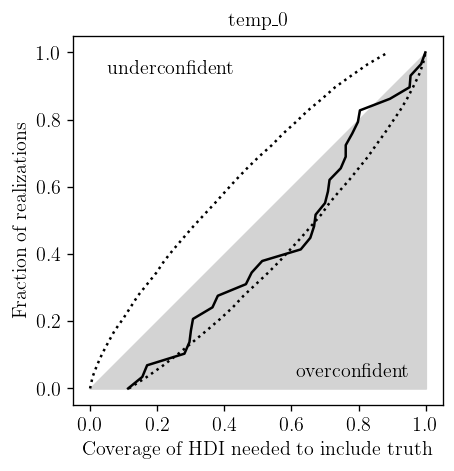

In [52]:
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
k = 'temp_0'

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
ax.plot(np.sort(p_runs), np.linspace(0, 1, n_run), color='k', label=k)

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% containment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
       title=f'{k}')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center');

In [ ]:
samples_dict = {'' : samples}
colors_dict = {'' : 'C0'}
labels_dict = {'' : 'test'}
plot_var_names = ['temp_0', 'temp_1', 'temp_2']
truth_dict = {f'temp_{i}' : t for i, t in enumerate(truth_arr)}
multi_corner(
    samples_dict, plot_var_names, MAP=truth_dict,
    colors_dict=colors_dict, labels_dict=labels_dict,
    hist_bin_factor=1
)

In [ ]:
jax.random.normal?

In [15]:


rng_key, key = jax.random.split(rng_key)
jax.random.normal(key, shape=()) * 0.1 + 3

Array(0.08887016, dtype=float32)